## Phase separation

Reference: The Cahn–Hilliard–Navier–Stokes framework
for multiphase fluid flows: laminar, turbulent and active
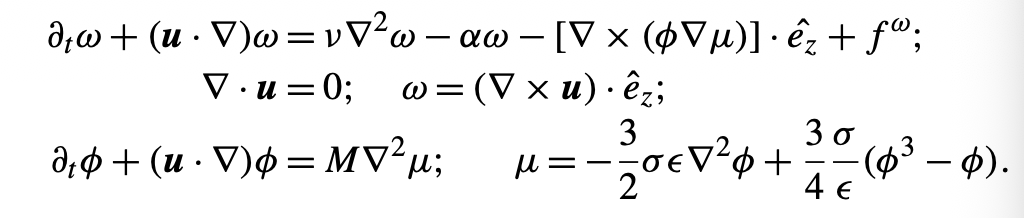
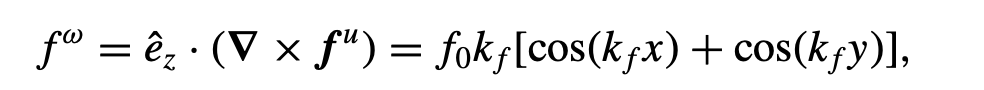
Reference: Interface-induced turbulence in viscous binary fluid mixtures
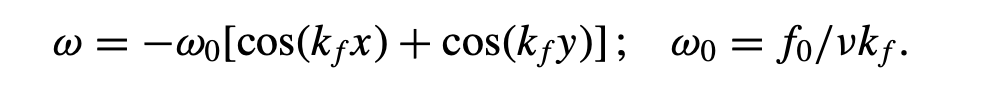
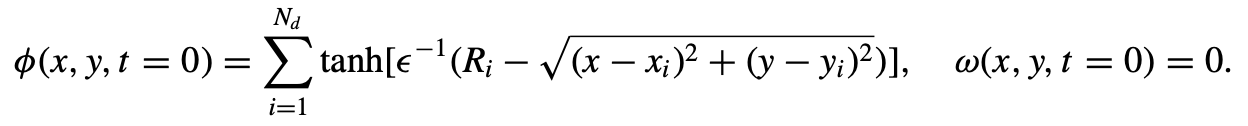

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy.linalg as la
import matplotlib.animation as animation

In [ ]:
## Grid has N^2 points (2D)
## Periodic domain (D = l^d), l = length of the side of d-dimensional hypercubic domain


# Domain 
L_x = 2*np.pi
L_y = 2*np.pi
N_x = 256
N_y = 256

# 2D periodic grid
del_x = L_x/N_x
del_y = L_y/N_y
x_j = np.arange(N_x) * del_x
y_j = np.arange(N_y) * del_y
X, Y = np.meshgrid(x_j, y_j, indexing='xy')

# Wrapped wavenumber arrays
n_x = np.arange(N_x)
n_y = np.arange(N_y)
k_x = (2*np.pi/L_x) * np.where(n_x <= N_x/2, n_x, n_x - N_x)
k_y = (2*np.pi/L_y) * np.where(n_y <= N_y/2, n_y, n_y - N_y)
Kx, Ky = np.meshgrid(k_x, k_y, indexing='xy')

K2 = Kx**2 + Ky**2

dx = 2*np.pi/N_x
# diffuse interface
epsilon = 3*dx
# 0.03
# 4*dx

# Kinematic velocity
nu = 0.04

# Friction coefficient
alpha = 0.0

# Mobility in Cahn-Hilliard equation
M = epsilon**2 
# 6e-4
# epsilon**2

# Low sigma could break the interface
sigma = 1.0

# \nu controls viscous damping in the vorticity equation
# alpha is an extra linear damping term
# M controls how strongly \phi diffuses through the chemical potential \mu

lamda_01 = -nu*K2 - alpha
lamda_02 = (-3/2)*M*sigma*epsilon*K2**2 + (3/4)*(sigma/epsilon)*M*K2 # M*sigma*epsilon*dt*K**4/2 or 3 must be less than 1, M and dt have inverse relation

# Reference for the following: Interface-induced turbulence in viscous binary fluid mixtures Supplemental Material
# Amplitude
f_0 = 0.4

k_f = 4 # Wavenumber
# also epsilon, alpha, nu, M

f_w = f_0 * k_f * (np.cos(k_f * X) + np.cos(k_f * Y))
f_w_hat = np.fft.fft2(f_w)

# Time stepping
T = 100.0
delta_t = 1e-5
N_t = 200000

# Radius of droplets
R = 1.0

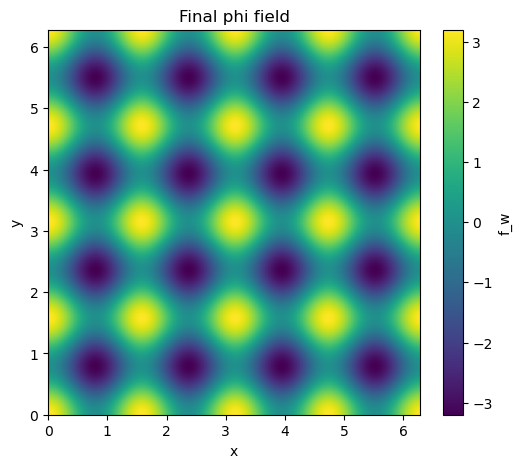

In [3]:
plt.figure(figsize=(6,5))
plt.imshow(f_w, origin='lower', extent=[0, L_x, 0, L_y], aspect='auto')
plt.colorbar(label='f_w')
plt.title('Final phi field')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [4]:
# Reference: Efficient Coding of the Minimum Image Convention
# Instead of the Euclidean distance, the minimum image convention is implemented for periodic BCs

def periodic_distance(X, Y, xc, yc, Lx, Ly):
    dx = X - xc
    dy = Y - yc
    # dx = (dx + Lx/2) % Lx - Lx/2
    # dy = (dy + Ly/2) % Ly - Ly/2
    return np.sqrt(dx**2 + dy**2)

def build_phi_rp2(X, Y, centers, radii, epsilon, Lx, Ly):
    phi = np.zeros_like(X)
    Nd = len(centers)

    for (xc, yc), R in zip(centers, radii):
        r = periodic_distance(X, Y, xc, yc, Lx, Ly)
        phi += np.tanh((R - r)/epsilon)

    phi += (Nd - 1)
    return phi

In [5]:
# Initial set-up

def make_square_droplet_array(Lx, Ly, nx, ny, margin_x=np.pi, margin_y=np.pi):
    """
    Create a regular nx-by-ny array of droplet centers in a periodic box.
    margin_x, margin_y let you keep droplets away from the edges if desired.
    """
    xs = np.linspace(margin_x, Lx - margin_x, nx, endpoint=False)
    ys = np.linspace(margin_y, Ly - margin_y, ny, endpoint=False)

    centers = []
    for y in ys:
        for x in xs:
            centers.append((x, y))
    return centers

# Dense droplet lattice (nx is the no. of droplets)
centers = make_square_droplet_array(L_x, L_y, nx=1, ny=1)

# Same radius for all droplets
radii = [R] * len(centers)

# phi

# phi_xy = np.zeros((N_y, N_x)) # only for laminar flow
phi_xy = build_phi_rp2(X, Y, centers, radii, epsilon, L_x, L_y)
phi_xy_hat = np.fft.fft2(phi_xy)

# Initial vorticity
omega_xy_0 = np.zeros((N_y, N_x))
omega_hat = np.fft.fft2(omega_xy_0)

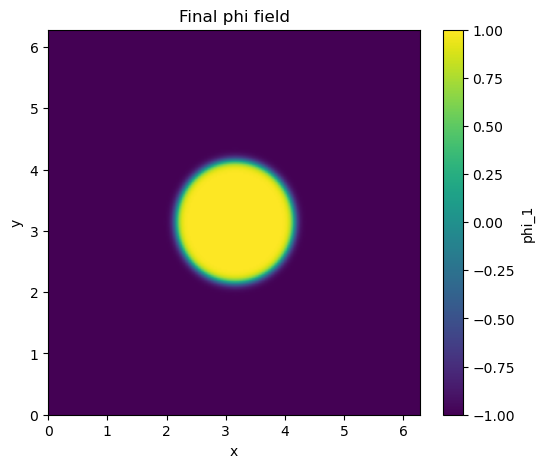

In [6]:
plt.figure(figsize=(6,5))
plt.imshow(phi_xy, origin='lower', extent=[0, L_x, 0, L_y], aspect='auto')
plt.colorbar(label='phi_1')
plt.title('Final phi field')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [7]:
# Integer Fourier mode indices for dealiasing
mx = np.fft.fftfreq(N_x) * N_x
my = np.fft.fftfreq(N_y) * N_y
MX, MY = np.meshgrid(mx, my, indexing='xy')

# 1/2-dealiasing mask for cubic nonlinearities
dealias_mask = ((np.abs(MX) < N_x//4) & (np.abs(MY) < N_y//4)).astype(float)

def dealias(hat_field):
    return hat_field * dealias_mask

In [8]:
# Assemble \mu using pseudo-spectral implementation

print("initial phi stats:", phi_xy.min(), phi_xy.max(), np.mean(phi_xy))
print("initial phi hat finite?", np.isfinite(phi_xy_hat).all())

def mu_spec(phi_hat, phi_xy):
    phi3_hat = dealias(np.fft.fft2(phi_xy**3))
    return (3/2)*sigma*epsilon*K2*phi_hat + (3/4)*(sigma/epsilon)*(phi3_hat - phi_hat)



initial phi stats: -1.0 0.9999999999968046 -0.8401353795548895
initial phi hat finite? True


In [9]:
# omega = vorticity field

def recover_velocity(omega_hat):
    psi_hat = np.zeros_like(omega_hat, dtype=complex)
    mask = (K2 != 0)
    psi_hat[mask] = omega_hat[mask] / K2[mask]

    u_x_hat = 1j * Ky * psi_hat
    u_y_hat = -1j * Kx * psi_hat

    u_x = np.fft.ifft2(u_x_hat).real
    u_y = np.fft.ifft2(u_y_hat).real

    return u_x,u_y

In [10]:
# Handling Non linear terms in CHNS equation

def advection_phi(phi_xy_hat, u_x, u_y):
    phi_x = np.fft.ifft2(1j * Kx * phi_xy_hat).real
    phi_y = np.fft.ifft2(1j * Ky * phi_xy_hat).real
    adv_xy = phi_x * u_x + phi_y * u_y
    return dealias(np.fft.fft2(adv_xy))

def advection_omega(omega_hat, u_x, u_y):
    omega_x = np.fft.ifft2(1j * Kx * omega_hat).real
    omega_y = np.fft.ifft2(1j * Ky * omega_hat).real
    adv_xy = omega_x * u_x + omega_y * u_y
    return dealias(np.fft.fft2(adv_xy))

# 2D vorticity equation
def coupling_term(phi_xy, mu_spec):
    mu_x = np.fft.ifft2(1j * Kx * mu_spec).real
    mu_y = np.fft.ifft2(1j * Ky * mu_spec).real

    term1_hat = dealias(np.fft.fft2(phi_xy * mu_y))
    term2_hat = dealias(np.fft.fft2(phi_xy * mu_x))

    return -(1j * Kx * term1_hat - 1j * Ky * term2_hat) # minus sign due to how coupling is defined in RP2

In [11]:
# Time stepping 

G = lambda omega_hat,phi_xy,mu_s,u_x,u_y: -(advection_omega(omega_hat,u_x,u_y)) + coupling_term(phi_xy,mu_s) + f_w_hat
H = lambda phi_xy_hat,phi_xy,u_x,u_y: -(advection_phi(phi_xy_hat,u_x,u_y)) - (3/4)*(sigma/epsilon)*M*K2*dealias(np.fft.fft2(phi_xy**3))


In [12]:
# Time stepping
q_01 = omega_hat
q_02 = phi_xy_hat

q_01_n = q_01
q_02_n = q_02

omega_history = [omega_xy_0.copy()]
phi_history = [np.fft.ifft2(q_02_n).real.copy()]
time_history = [0.0]

save_every = 100


# Masked handling for lambda = 0
E_01 = np.exp(lamda_01*delta_t)
E_02 = np.exp(lamda_02*delta_t)

mask_01 = (np.abs(lamda_01) > 1e-14)
mask_02 = (np.abs(lamda_02) > 1e-14)

# Masked handling for lambda = 0

phi1 = np.empty_like(lamda_01, dtype=complex)
phi2 = np.empty_like(lamda_02, dtype=complex)

phi1[mask_01] = (E_01[mask_01] - 1)/lamda_01[mask_01]
phi2[mask_02] = (E_02[mask_02] - 1)/lamda_02[mask_02]

phi1[~mask_01] = delta_t
phi2[~mask_02] = delta_t

phi_1 = np.empty_like(lamda_01, dtype=complex)
phi_2 = np.empty_like(lamda_02, dtype=complex)

phi_1[mask_01] = (E_01[mask_01] - 1 - lamda_01[mask_01] * delta_t)/(lamda_01[mask_01]**2 * delta_t)
phi_2[mask_02] = (E_02[mask_02] - 1 - lamda_02[mask_02] * delta_t)/(lamda_02[mask_02]**2 * delta_t)

phi_1[~mask_01] = 0.5 * delta_t
phi_2[~mask_02] = 0.5 * delta_t

for n in range(0,N_t):
    # Block A: Recomputation

    # A.1) Extracting velocity from omega_hat_n
    u_x_n,u_y_n = recover_velocity(q_01_n)

    # A.2) Re-computing terms
    phi_intermediate = np.fft.ifft2(q_02_n).real
    mu_spec_n = mu_spec(q_02_n,phi_intermediate)

    # A.3) Non-linear terms
    G_n = G(q_01_n,phi_intermediate,mu_spec_n,u_x_n,u_y_n)
    H_n = H(q_02_n,phi_intermediate,u_x_n,u_y_n)

    # Block B: Predictor

    a_01_n = q_01_n * np.exp(lamda_01 * delta_t) + (G_n * phi1)
    a_02_n = q_02_n * np.exp(lamda_02 * delta_t) + (H_n * phi2)

    # Block C: Intermediate state reconstruction
    # C.1) Recover velocity from a_01_n
    u_x_a, u_y_a = recover_velocity(a_01_n)

    # C.2) Recover phi from a_02_n
    phi_a = np.fft.ifft2(a_02_n).real
    mu_spec_a = mu_spec(a_02_n,phi_a)

    # Block D: Final assembly

    G_a = G(a_01_n,phi_a,mu_spec_a,u_x_a,u_y_a)
    H_a = H(a_02_n,phi_a,u_x_a,u_y_a)

    q_01_next = a_01_n + (G_a - G_n) * phi_1
    q_02_next = a_02_n + (H_a - H_n) * phi_2

    if not np.isfinite(q_01_next).all() or not np.isfinite(q_02_next).all():
        print("NaN/Inf detected at step", n)
        break

    q_01_next = dealias(q_01_next)
    q_02_next = dealias(q_02_next)

    if (n + 1) % save_every == 0:
        omega_history.append(np.fft.ifft2(q_01_n).real.copy())
        phi_history.append(np.fft.ifft2(q_02_n).real.copy())
        time_history.append((n + 1) * delta_t)

    if n % 1000 == 0:
        print(f"step {n}/{N_t}")
    
    # Final omega hat
    q_01_n = q_01_next
    # omega_history.append(np.fft.ifft2(q_01_n).real)

    # Final phi_hat
    q_02_n = q_02_next
    # phi_history.append(np.fft.ifft2(q_02_n).real)

step 0/200000
step 1000/200000
step 2000/200000
step 3000/200000
step 4000/200000
step 5000/200000
step 6000/200000
step 7000/200000
step 8000/200000
step 9000/200000
step 10000/200000
step 11000/200000
step 12000/200000
step 13000/200000
step 14000/200000
step 15000/200000
step 16000/200000
step 17000/200000
step 18000/200000
step 19000/200000
step 20000/200000
step 21000/200000
step 22000/200000
step 23000/200000
step 24000/200000
step 25000/200000
step 26000/200000
step 27000/200000
step 28000/200000
step 29000/200000
step 30000/200000
step 31000/200000
step 32000/200000
step 33000/200000
step 34000/200000
step 35000/200000
step 36000/200000
step 37000/200000
step 38000/200000
step 39000/200000
step 40000/200000
step 41000/200000
step 42000/200000
step 43000/200000
step 44000/200000
step 45000/200000
step 46000/200000
step 47000/200000
step 48000/200000
step 49000/200000
step 50000/200000
step 51000/200000
step 52000/200000
step 53000/200000
step 54000/200000
step 55000/200000
step 

In [13]:
print("Run completed with T =", T, "N_t =", N_t, "delta_t =", delta_t)
print("omega final min/max:", omega_history[-1].min(), omega_history[-1].max())
print("len(omega_history) =", len(omega_history))

Run completed with T = 100.0 N_t = 200000 delta_t = 1e-05
omega final min/max: -3.6096258038401836 3.609844750207727
len(omega_history) = 2001


In [14]:
print("final phi stats:", phi_history[-1].min(), phi_history[-1].max(), np.mean(phi_history[-1]))
print("final omega stats:", omega_history[-1].min(), omega_history[-1].max())
print("all phi finite?", np.isfinite(np.array(phi_history)).all())
print("all omega finite?", np.isfinite(np.array(omega_history)).all())

final phi stats: -1.0062743127968337 1.034347945712398 -0.8401353795548896
final omega stats: -3.6096258038401836 3.609844750207727
all phi finite? True
all omega finite? True


In [15]:
# Pointers

## 1) may need to use Google Collab, numpy might be too slow
## 2) Validation Techniques - look up research papers on it - vary time-stepping techniques/grid points & compute the error 
## 3) Simulate phase separation
## 4) Look up on relations between parameters 
## 5) Additional - Mean square displacement

In [16]:
phi_mean = []

for i in range(len(phi_history)):
    phi_mean.append(np.mean(phi_history[i]))

phi_mean_check = np.array(phi_mean)   # one value per time step
m0 = phi_mean[0]

abs_drift = np.abs(phi_mean_check - m0)
rel_drift = abs_drift / max(abs(m0), 1e-14)

print("max abs drift =", abs_drift.max())
print("max rel drift =", rel_drift.max())
print(m0)


max abs drift = 3.3306690738754696e-16
max rel drift = 3.96444329679353e-16
-0.8401353795548895


In [17]:
# Since m0 is almost close to roundoff-level zero, dividing by such a number results into 
# arbitrarily large output. Thus, we use abs_drift. 

# plt.semilogy(abs_drift)
# plt.semilogy(rel_drift)

In [18]:
phi_max = []

for i in range(len(phi_history)):
    phi_max.append(np.max(np.abs(phi_history[i])))

omega_max = []

for i in range(len(omega_history)):
    omega_max.append(np.max(np.abs(omega_history[i])))

phi_max_check = np.array(phi_max)
omega_max_check = np.array(omega_max)

print("max |phi| =", phi_max_check.max())
print("max |omega| =", omega_max_check.max())
print("all finite phi?", np.isfinite(phi_max_check).all())
print("all finite omega?", np.isfinite(omega_max_check).all())


max |phi| = 1.0450271799544244
max |omega| = 3.609844750207727
all finite phi? True
all finite omega? True


Text(0.5, 1.0, 'max |omega| over time')

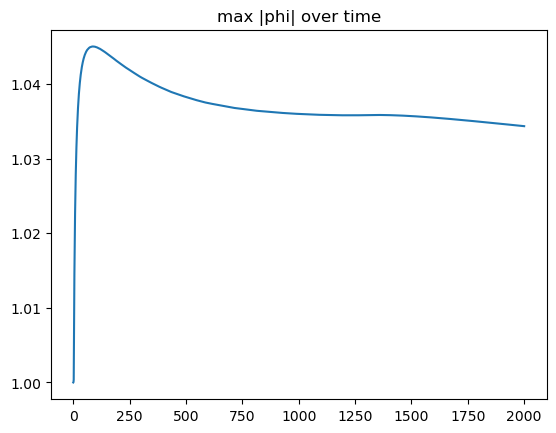

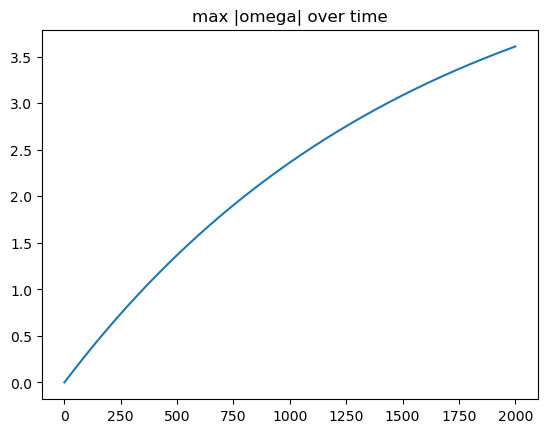

In [19]:
plt.plot(phi_max)
plt.title("max |phi| over time")

plt.figure()
plt.plot(omega_max)
plt.title("max |omega| over time")

In [20]:
omega_xy_final = np.fft.ifft2(q_01_n).real
phi_xy_final   = np.fft.ifft2(q_02_n).real

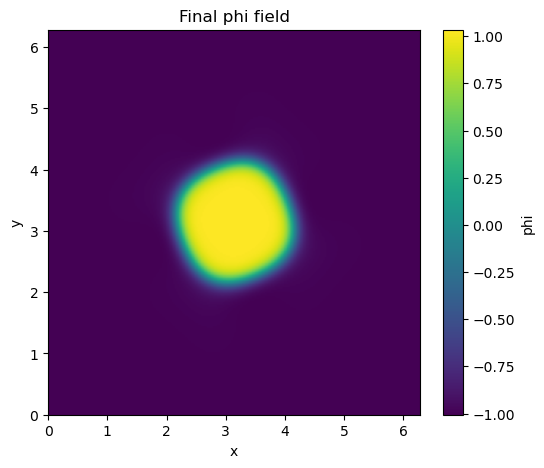

In [21]:
plt.figure(figsize=(6,5))
plt.imshow(phi_xy_final, origin='lower', extent=[0, L_x, 0, L_y], aspect='auto')
plt.colorbar(label='phi')
plt.title('Final phi field')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

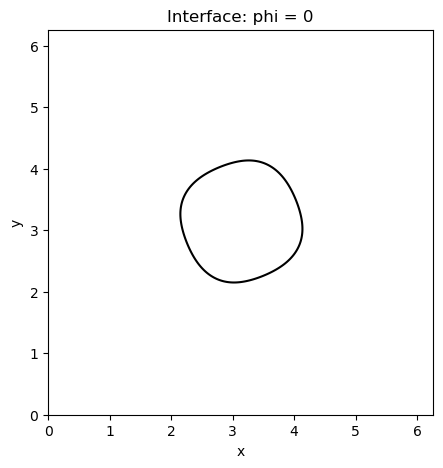

In [22]:
plt.figure(figsize=(6,5))
plt.contour(X, Y, phi_xy_final, levels=[0], colors='k')
plt.title('Interface: phi = 0')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')
plt.show()

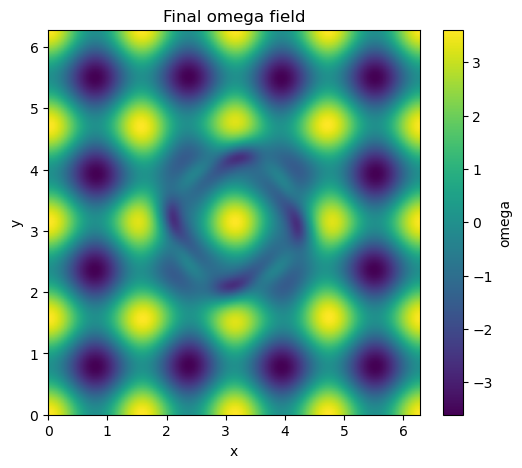

In [23]:
plt.figure(figsize=(6,5))
plt.imshow(omega_xy_final, origin='lower', extent=[0, L_x, 0, L_y], aspect='auto')
plt.colorbar(label='omega')
plt.title('Final omega field')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

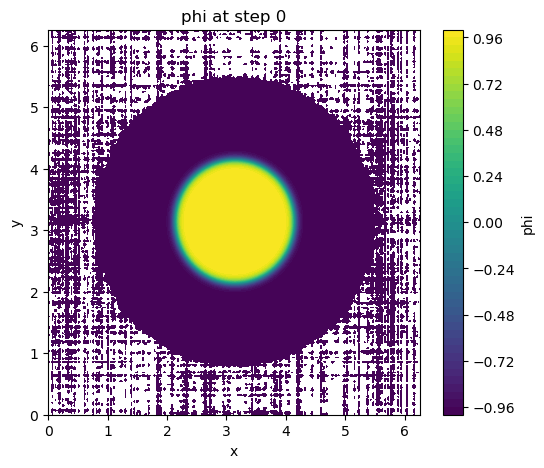

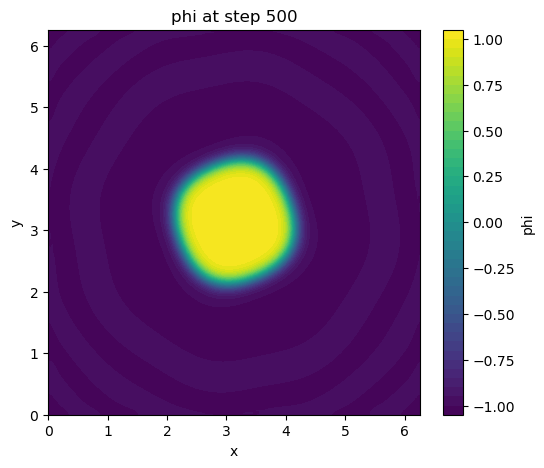

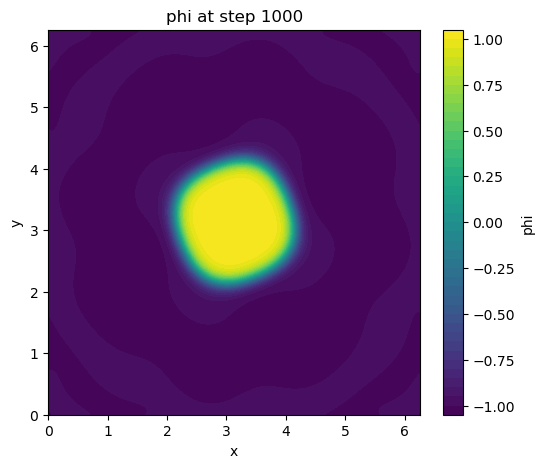

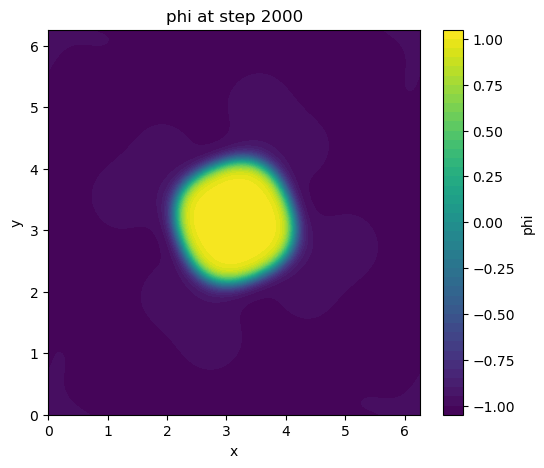

In [24]:
times_to_plot = [0, len(phi_history)//4,len(phi_history)//2, len(phi_history)-1]

for idx in times_to_plot:
    plt.figure(figsize=(6,5))
    plt.contourf(X, Y, phi_history[idx], levels=50)
    plt.colorbar(label='phi')
    plt.title(f'phi at step {idx}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

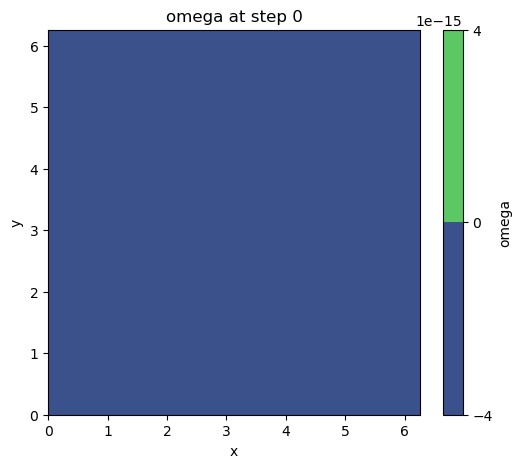

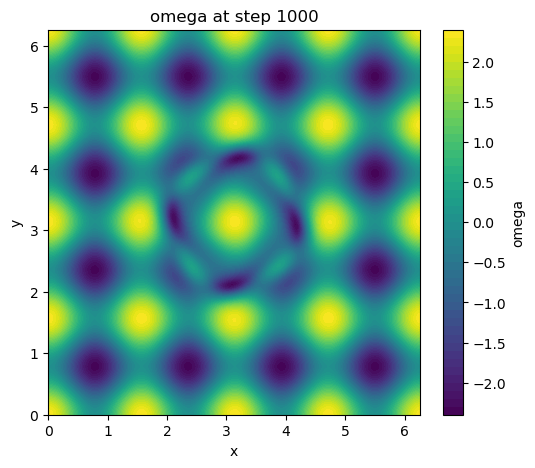

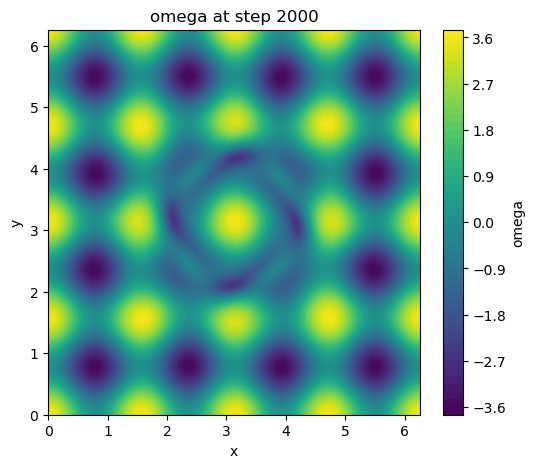

In [25]:
times_to_plot = [0, len(omega_history)//2, len(omega_history)-1]

for idx in times_to_plot:
    plt.figure(figsize=(6,5))
    plt.contourf(X, Y, omega_history[idx], levels=50)
    plt.colorbar(label='omega')
    plt.title(f'omega at step {idx}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

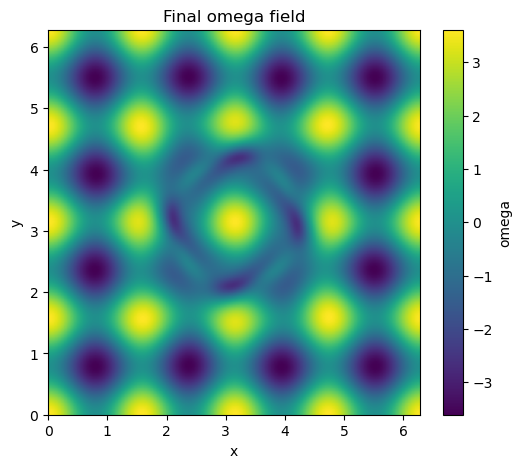

In [26]:
om = omega_xy_final
v = np.max(np.abs(om))

plt.figure(figsize=(6,5))
plt.imshow(om, origin='lower', extent=[0, L_x, 0, L_y], vmin=-v, vmax=v, aspect='auto')
plt.colorbar(label='omega')
plt.title('Final omega field')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [27]:
id="first_step_growth"
print(np.min(omega_history[0]), np.max(omega_history[0]))
print(np.min(omega_history[1]), np.max(omega_history[1]))

0.0 0.0
-0.0031860519223780993 0.003166996659371849


In [28]:
len(phi_history)

2001

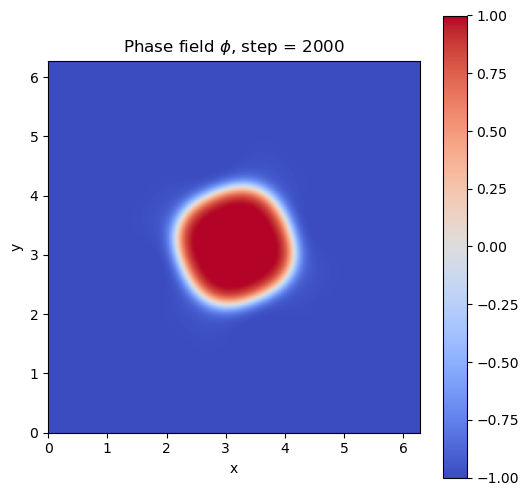

In [29]:
fig, ax = plt.subplots(figsize=(6,6))

im = ax.imshow(
    phi_history[0],
    origin='lower',
    extent=[0, L_x, 0, L_y],
    cmap='coolwarm',
    animated=True
)
ax.set_title("Phase field $\\phi$")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax)

def update(frame):
    im.set_array(phi_history[frame])
    ax.set_title(f"Phase field $\\phi$, step = {frame}")
    return [im]

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(phi_history),
    interval=50,
    blit=True
)

ani.save("phi_animation.gif", writer="pillow", fps=15)
plt.show()

In [30]:
print(phi_history[0].min(), phi_history[0].max(), np.mean(phi_history[0]))

-1.0000000000000009 0.9999999999968047 -0.8401353795548895


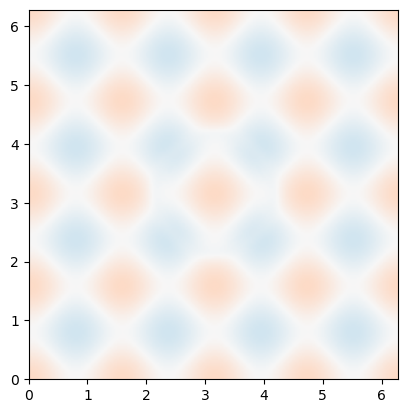

In [31]:
omega_plot = omega_history[200]
plt.imshow(omega_plot, origin='lower', extent=[0,L_x,0,L_y], cmap='RdBu_r', vmin=-3, vmax=3)

### Validation:

#### Check 01 - Single-fluid laminar cellular solution (phi,omega = 0 and alpha = 0)
#### Check 02 — Initial droplet-field validation
#### Check 03 — Conservation and numerical stability (for full CHNS with forcing)
#### Check 04 - Energy and coarsening diagnostics
#### Check 05 - Regime classification and refinement

In [32]:
# omega_lam = -(f_0 / (nu * k_f)) * (np.cos(k_f * X) + np.cos(k_f * Y))

# omega_num = omega_history[-1]
# err = omega_num - omega_lam

# err_L2 = np.sqrt(1/(N_x*N_y)*np.sum(np.sum(np.abs(err)**2)))
# err_Linf = np.max(np.abs(err))

# print("Laminar validation:")
# print("L2 error   =", err_L2)
# print("Linf error =", err_Linf)

In [33]:
# Validation 02: Conservation and numerical stability

phi_mean_hist = [np.mean(phi) for phi in phi_history]
phi_min_hist  = [np.min(phi) for phi in phi_history]
phi_max_hist  = [np.max(phi) for phi in phi_history]

omega_min_hist = [np.min(w) for w in omega_history]
omega_max_hist = [np.max(w) for w in omega_history]

print("Mean phi drift =", np.max(np.abs(np.array(phi_mean_hist) - phi_mean_hist[0])))
print("All phi finite?  ", np.isfinite(np.array(phi_history)).all())
print("All omega finite?", np.isfinite(np.array(omega_history)).all())

Mean phi drift = 3.3306690738754696e-16
All phi finite?   True
All omega finite? True


In [34]:
# Validation 03: Energy and coarsening diagnostics

# Kinetic energy
energy_hist = []

for w_hat in [np.fft.fft2(w) for w in omega_history]:
    u_x, u_y = recover_velocity(w_hat)
    e_t = 0.5 * np.mean(u_x**2 + u_y**2)
    energy_hist.append(e_t)

# Shell-averaged phase spectrum and coarsening length

def shell_average_phi(phi_hat, K2):
    k_mag = np.sqrt(K2)
    k_max = int(np.floor(np.max(k_mag)))
    S = np.zeros(k_max + 1)

    for k in range(k_max + 1):
        mask = (k_mag >= k) & (k_mag < k + 1)
        if np.any(mask):
            S[k] = np.sum(np.abs(phi_hat[mask])**2)
    return S

L_hist = []

for phi in phi_history:
    phi_hat = np.fft.fft2(phi)
    S = shell_average_phi(phi_hat, K2)
    kvals = np.arange(len(S))

    # Exclude k=0 shell
    S_use = S[1:]
    k_use = kvals[1:]

    numer = np.sum(S_use)
    denom = np.sum(k_use * S_use)

    if denom > 1e-14 and numer > 1e-14:
        L_t = 2*np.pi * numer / denom
    else:
        L_t = np.nan

    L_hist.append(L_t)

L_arr = np.array(L_hist)

print("L(t) stats:")
print("min =", np.nanmin(L_arr))
print("max =", np.nanmax(L_arr))
print("all finite?", np.isfinite(L_arr).all())

L(t) stats:
min = 2.965924924654568
max = 3.5559650440708714
all finite? True


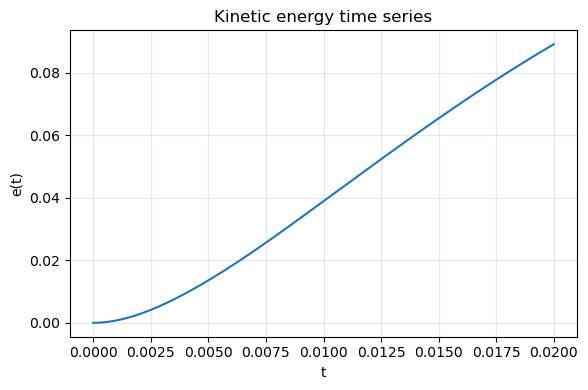

In [35]:
t_arr = np.arange(len(energy_hist)) * delta_t

plt.figure(figsize=(6,4))
plt.plot(t_arr, energy_hist, lw=1.5)
plt.xlabel("t")
plt.ylabel("e(t)")
plt.title("Kinetic energy time series")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

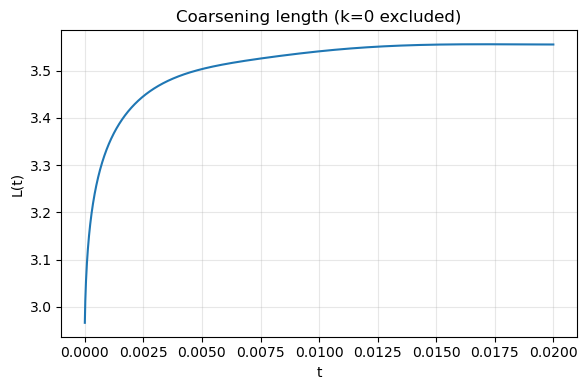

In [36]:
L_arr = np.array(L_hist)

plt.figure(figsize=(6,4))
plt.plot(t_arr, L_arr, lw=1.5)
plt.xlabel("t")
plt.ylabel("L(t)")
plt.title("Coarsening length (k=0 excluded)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

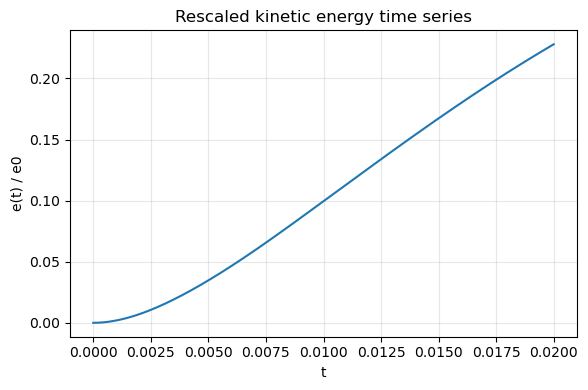

In [37]:
# Validation 04 - Regime classification and refinement

U = f_0 / (nu * k_f**2)
e0 = U**2

energy_hist = np.array(energy_hist)
energy_hist_scaled = energy_hist / e0
t_arr = np.arange(len(energy_hist_scaled)) * delta_t

plt.figure(figsize=(6,4))
plt.plot(t_arr, energy_hist_scaled, lw=1.5)
plt.xlabel("t")
plt.ylabel("e(t) / e0")
plt.title("Rescaled kinetic energy time series")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

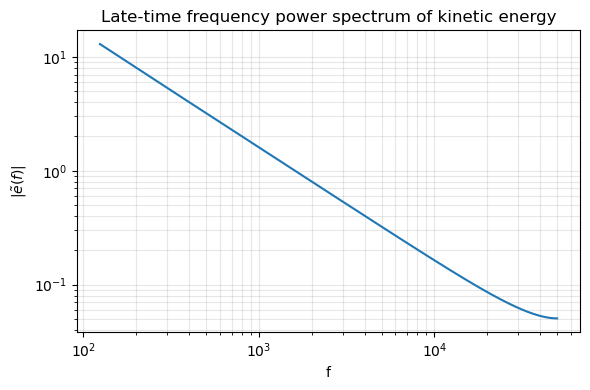

In [38]:
# A - Frequency spectrum of e(t)

e_arr = np.array(energy_hist_scaled)

# remove transient
start_frac = 0.6
i0 = int(start_frac * len(e_arr))

e_late = e_arr[i0:] - np.mean(e_arr[i0:])
e_fft = np.fft.rfft(e_late)
freqs = np.fft.rfftfreq(len(e_late), d=delta_t)

power_amp = np.abs(e_fft)     # closer to RP2 notation |\tilde e(f)|

plt.figure(figsize=(6,4))
plt.loglog(freqs[1:], power_amp[1:], lw=1.5)
plt.xlabel("f")
plt.ylabel(r"$|\tilde e(f)|$")
plt.title("Late-time frequency power spectrum of kinetic energy")
plt.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

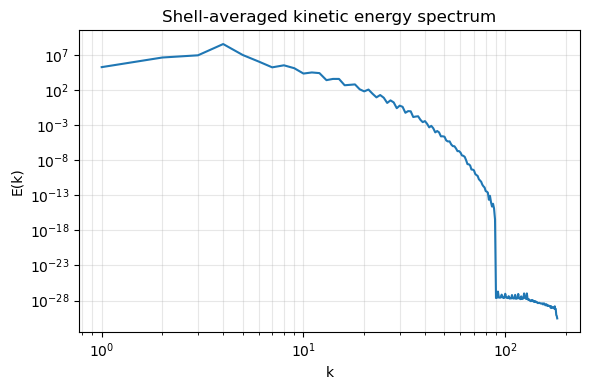

In [39]:
# B. Shell-averaged kinetic energy spectrum

def shell_average_energy(u_x_hat, u_y_hat, K2):
    k_mag = np.sqrt(K2)
    k_max = int(np.floor(np.max(k_mag)))
    E = np.zeros(k_max + 1)

    energy_density = 0.5 * (np.abs(u_x_hat)**2 + np.abs(u_y_hat)**2)

    for k in range(k_max + 1):
        mask = (k_mag >= k) & (k_mag < k + 1)
        if np.any(mask):
            E[k] = np.sum(energy_density[mask])

    return E

omega_hat_final = np.fft.fft2(omega_history[-1])
psi_hat = np.zeros_like(omega_hat_final, dtype=complex)
mask = (K2 != 0)
psi_hat[mask] = omega_hat_final[mask] / K2[mask]

u_x_hat = 1j * Ky * psi_hat
u_y_hat = -1j * Kx * psi_hat

E_k = shell_average_energy(u_x_hat, u_y_hat, K2)
kvals = np.arange(len(E_k))

plt.figure(figsize=(6,4))
plt.loglog(kvals[1:], E_k[1:], lw=1.5)
plt.xlabel("k")
plt.ylabel("E(k)")
plt.title("Shell-averaged kinetic energy spectrum")
plt.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

In [40]:
# # B. Grid/timestep refinement

# run256 = {
#     "phi_history": phi_history_256,
#     "omega_history": omega_history_256,
#     "energy_hist": energy_hist_256,
#     "L_hist": L_hist_256,
#     "delta_t": delta_t_256
# }

# run512 = {
#     "phi_history": phi_history_512,
#     "omega_history": omega_history_512,
#     "energy_hist": energy_hist_512,
#     "L_hist": L_hist_512,
#     "delta_t": delta_t_512
# }

# fig, axes = plt.subplots(2, 2, figsize=(10,8))

# im0 = axes[0,0].imshow(run256["phi_history"][-1], origin='lower', extent=[0,L_x,0,L_y], cmap='viridis')
# axes[0,0].set_title("phi final (256)")
# plt.colorbar(im0, ax=axes[0,0])

# im1 = axes[0,1].imshow(run512["phi_history"][-1], origin='lower', extent=[0,L_x,0,L_y], cmap='viridis')
# axes[0,1].set_title("phi final (512)")
# plt.colorbar(im1, ax=axes[0,1])

# im2 = axes[1,0].imshow(run256["omega_history"][-1], origin='lower', extent=[0,L_x,0,L_y], cmap='RdBu_r')
# axes[1,0].set_title("omega final (256)")
# plt.colorbar(im2, ax=axes[1,0])

# im3 = axes[1,1].imshow(run512["omega_history"][-1], origin='lower', extent=[0,L_x,0,L_y], cmap='RdBu_r')
# axes[1,1].set_title("omega final (512)")
# plt.colorbar(im3, ax=axes[1,1])

# plt.tight_layout()
# plt.show()

# t256 = np.arange(len(run256["energy_hist"])) * run256["delta_t"]
# t512 = np.arange(len(run512["energy_hist"])) * run512["delta_t"]

# fig, axes = plt.subplots(1, 2, figsize=(10,4))

# axes[0].plot(t256, run256["energy_hist"], label="256")
# axes[0].plot(t512, run512["energy_hist"], label="512")
# axes[0].set_xlabel("t")
# axes[0].set_ylabel("e(t)")
# axes[0].set_title("Kinetic energy")
# axes[0].legend()
# axes[0].grid(True, alpha=0.3)

# axes[1].plot(t256, run256["L_hist"], label="256")
# axes[1].plot(t512, run512["L_hist"], label="512")
# axes[1].set_xlabel("t")
# axes[1].set_ylabel("L(t)")
# axes[1].set_title("Coarsening length")
# axes[1].legend()
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# def power_spectrum_from_energy(energy_hist, delta_t, start_frac=0.5):
#     e = np.array(energy_hist)
#     i0 = int(start_frac * len(e))
#     e = e[i0:] - np.mean(e[i0:])
#     e_fft = np.fft.rfft(e)
#     freqs = np.fft.rfftfreq(len(e), d=delta_t)
#     power = np.abs(e_fft)**2
#     return freqs, power

# f256, p256 = power_spectrum_from_energy(run256["energy_hist"], run256["delta_t"])
# f512, p512 = power_spectrum_from_energy(run512["energy_hist"], run512["delta_t"])

# plt.figure(figsize=(6,4))
# plt.loglog(f256[1:], p256[1:], label="256")
# plt.loglog(f512[1:], p512[1:], label="512")
# plt.xlabel("f")
# plt.ylabel(r"$|\tilde e(f)|^2$")
# plt.title("Late-time energy spectra")
# plt.legend()
# plt.grid(True, alpha=0.3, which='both')
# plt.tight_layout()
# plt.show()

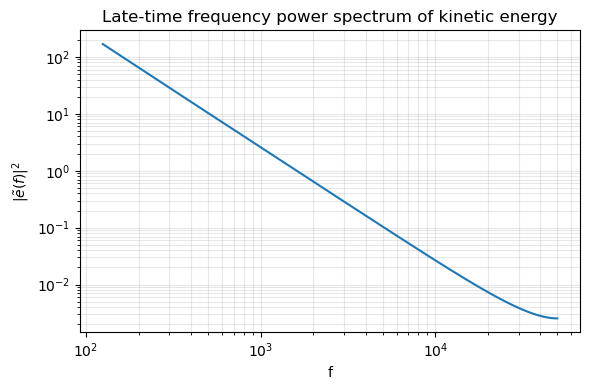

In [41]:
e_late = e_arr[i0:] - np.mean(e_arr[i0:])

e_fft = np.fft.rfft(e_late)
freqs = np.fft.rfftfreq(len(e_late), d=delta_t)
power = np.abs(e_fft)**2

plt.figure(figsize=(6,4))
plt.loglog(freqs[1:], power[1:], lw=1.5)
plt.xlabel("f")
plt.ylabel(r"$|\tilde e(f)|^2$")
plt.title("Late-time frequency power spectrum of kinetic energy")
plt.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

In [42]:
peak_idx = np.argmax(power[1:]) + 1
print("dominant frequency =", freqs[peak_idx])
print("dominant power =", power[peak_idx])

# crude broadband measure
power_tail = np.sum(power[2:]) / np.sum(power[1:])
print("fraction of power away from first nonzero mode =", power_tail)

dominant frequency = 124.84394506866414
dominant power = 168.0349409642484
fraction of power away from first nonzero mode = 0.38932922008543835
